📦 Sample Data:
   review_id                                        review_text
0          1  The phone has a great battery life and excelle...
1          2  Poor performance and very slow. Not recommende...
2          3  Decent features for the price, but the screen ...
3          4  Absolutely love this laptop. Fast, lightweight...
4          5  Terrible product. It stopped working after a w...

📊 Bag of Words (BoW) Matrix:
   absolutely  battery  camera  decent  design  excellent  fast  features  \
0           0        1       1       0       0          1     0         0   
1           0        0       0       0       0          0     0         0   
2           0        0       0       1       0          0     0         1   
3           1        0       0       0       1          0     1         0   
4           0        0       0       0       0          0     0         0   

   great  laptop  ...  recommended  screen  sleek  slow  small  stopped  \
0      1       0  ...            

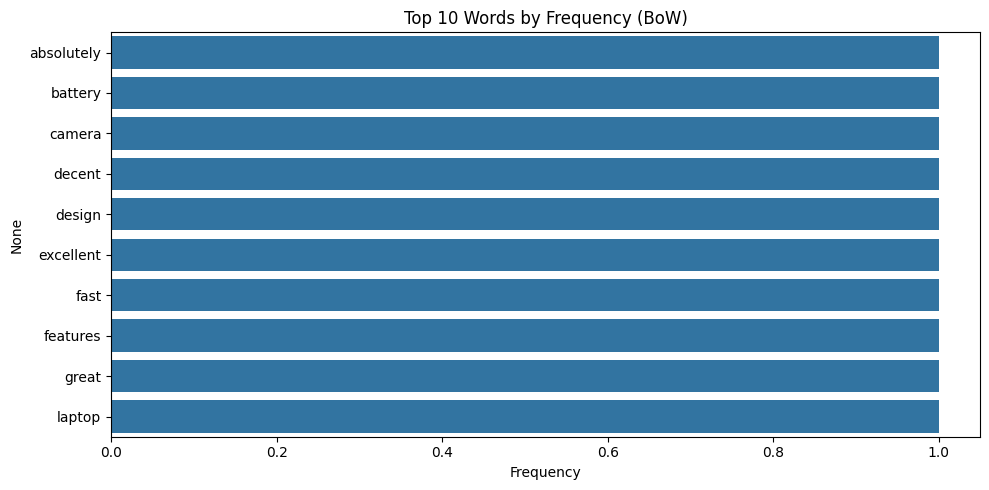

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt


data = {
    "review_id": [1, 2, 3, 4, 5],
    "review_text": [
        "The phone has a great battery life and excellent camera quality.",
        "Poor performance and very slow. Not recommended at all!",
        "Decent features for the price, but the screen is too small.",
        "Absolutely love this laptop. Fast, lightweight and sleek design!",
        "Terrible product. It stopped working after a week of use."
    ]
}


df = pd.DataFrame(data)

print("📦 Sample Data:")
print(df.head())

print("\n📊 Bag of Words (BoW) Matrix:")
bow_vectorizer = CountVectorizer(stop_words='english')  
bow_matrix = bow_vectorizer.fit_transform(df["review_text"])
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print(bow_df)

# Show Top 10 most common words
bow_word_freq = bow_df.sum().sort_values(ascending=False)
print("\n🔥 Top 10 Frequent Words (BoW):")
print(bow_word_freq.head(10))


print("\n📊 TF-IDF Matrix:")
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df["review_text"])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
print(tfidf_df)

# Show Top 10 TF-IDF words 
top_tfidf = pd.Series(tfidf_df.loc[0]).sort_values(ascending=False)
print("\n🔍 Top TF-IDF Words for Review 1:")
print(top_tfidf.head(10))


plt.figure(figsize=(10, 5))
sns.barplot(x=bow_word_freq.head(10).values, y=bow_word_freq.head(10).index)
plt.title("Top 10 Words by Frequency (BoW)")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()
